# Practical 2
## Pandas + Access, Assess, Address
Radzim Sendyka, Neil Lawrence

## Code Reuse
We will be reusing some of the functions we created in the first practical.

### Exercise 0
Install your Fynesse library, and run code to show it's available.

In [ ]:
%%capture
%pip install osmnx
!git clone https://github.com/TODO/TODO.git
import os, subprocess, importlib, sys
sys.path.append("/content/fynesse_TODO")
import fynesse

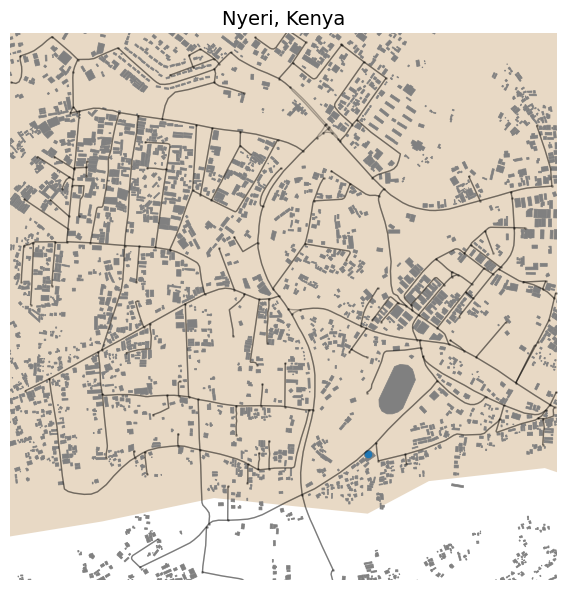

In [ ]:
#TODO Exercise 0
# eg. fynesse.access.plot_city_map('Nyeri, Kenya', -0.4371, 36.9580, 2)

## DSAIL-Porini dataset

Head over to https://data.mendeley.com/datasets/6mhrhn7rxc/6 to explore the DSAIL-Porini dataset, which you might already be familiar with. Locate the [`camera_trap_dataset_annotation.xlsx`](https://data.mendeley.com/public-files/datasets/6mhrhn7rxc/files/641e83c9-16a3-485c-b247-b5701f8a5540/file_downloaded) file and make it available in this notebook.

In [ ]:
import os
import requests
import pandas as pd

def download_if_not_exists(url, filepath):
    if os.path.exists(filepath):
        print(f"File already exists: {filepath}")
    else:
        print(f"Downloading: {url}")
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(filepath, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded to: {filepath}")
    return filepath

porini_file = download_if_not_exists('https://data.mendeley.com/public-files/datasets/6mhrhn7rxc/files/641e83c9-16a3-485c-b247-b5701f8a5540/file_downloaded', 'camera_trap_dataset_annotation.xlsx')
porini_df = pd.read_excel(porini_file)
porini_df.head()

Downloading: https://data.mendeley.com/public-files/datasets/6mhrhn7rxc/files/641e83c9-16a3-485c-b247-b5701f8a5540/file_downloaded
Downloaded to: camera_trap_dataset_annotation.xlsx


,Filename,Device,Species,Count,Sex,Latitude,Longitude
0,2021-08-01-07-31-10.jpg,Raspberry Pi 2,IMPALA,4,"MALE,FEMALE,FEMALE,FEMALE",-0.390386,36.962348
1,2021-08-01-07-31-13.jpg,Raspberry Pi 2,IMPALA,2,"MALE,FEMALE",-0.390386,36.962348
2,2021-08-01-07-31-35.jpg,Raspberry Pi 2,IMPALA,2,FEMALE,-0.390386,36.962348
3,2021-08-01-07-31-41.jpg,Raspberry Pi 2,IMPALA,2,FEMALE,-0.390386,36.962348
4,2021-08-01-07-31-45.jpg,Raspberry Pi 2,IMPALA,1,FEMALE,-0.390386,36.962348


### Joining Datasets

### Exercise 1

Geospatial data is particularly useful because it is the most common index in the world, over which so many datasets can be joined. Find the coordinate information in the dataset, and plot it on top of a OSM map.

You may want to deduplicate the coordinates before you plot!

In [ ]:
#TODO Exercise 1

## Sighting predictions

We will use the dataset to create a simple prediction model for the likelihood of animal sightings.

Let's follow a minimal example of the Access-Assess-Address framework!

Reminder about Neil's article on the framework [here](https://inverseprobability.com/talks/notes/access-assess-address-a-pipeline-for-automated-data-science.html).

### Access
Access is already done, partly years ago by the DSAIL team, and two cells above by us. Example tasks within access would be:
- Setting up the cameras in the woods (done)
- Collecting the pictures (done)
- Labeling the dataset (done)
- Making the excel file online accessible (done)
- Downloading the file (done just now)

In [ ]:
porini_df.head()

,Filename,Device,Species,Count,Sex,Latitude,Longitude
0,2021-08-01-07-31-10.jpg,Raspberry Pi 2,IMPALA,4,"MALE,FEMALE,FEMALE,FEMALE",-0.390386,36.962348
1,2021-08-01-07-31-13.jpg,Raspberry Pi 2,IMPALA,2,"MALE,FEMALE",-0.390386,36.962348
2,2021-08-01-07-31-35.jpg,Raspberry Pi 2,IMPALA,2,FEMALE,-0.390386,36.962348
3,2021-08-01-07-31-41.jpg,Raspberry Pi 2,IMPALA,2,FEMALE,-0.390386,36.962348
4,2021-08-01-07-31-45.jpg,Raspberry Pi 2,IMPALA,1,FEMALE,-0.390386,36.962348


### Assess

Have a look at the dataset for any issues that could stop us from being able to cleanly analyse it.

Some issues:
- Timestamps not readilly available. Hidden in image filenames.
- No timestamps available for one of the cameras.
- No Camera ID, but can be deduced from coordinates.

Decide how it would be best to address these and potentially other issues with the data.

We would like an output dataframe that has a column for counts each animal was spotted by each camera, and rows for each day in the available range. You might want to use this opportunity to practice [Pandas MultiIndex](https://pandas.pydata.org/docs/user_guide/advanced.html).

In [ ]:
import pandas as pd
import numpy as np
import re

# Copy original
df = porini_df.copy()

# Normalize species and parse counts
df["Species"] = df["Species"].astype(str).str.strip()

# Extract timestamp from filename
pat = re.compile(r"(\d{4})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})")
def parse_ts(name):
    m = pat.search(str(name))
    if not m:
        return pd.NaT
    y, M, d, h, m_, s = map(int, m.groups())
    return pd.Timestamp(y, M, d, h, m_, s)

df["timestamp"] = df["Filename"].map(parse_ts)
df["date"] = df["timestamp"].dt.date

# Camera ID from rounded lat/lon
df["Latitude"] = df["Latitude"].round(4)
df["Longitude"] = df["Longitude"].round(4)
coord_key = df["Latitude"].astype(str) + "," + df["Longitude"].astype(str)
codes, _ = pd.factorize(coord_key)
df["camera_id"] = pd.Series(codes).map(lambda i: f"C{int(i)+1:03d}")

# Extract camera coordinates dictionary (rounded)
camera_coords = (
    df.drop_duplicates(subset="camera_id")[["camera_id", "Latitude", "Longitude"]]
      .set_index("camera_id")
      .sort_index()
      .apply(tuple, axis=1)
      .to_dict()
)

# Group and count: number of pictures per species per camera per day
daily = (
    df.dropna(subset=["date"])
      .groupby(["date", "camera_id", "Species"])
      .size()
      .reset_index(name="photo_count")
      .pivot_table(index="date", columns=["camera_id", "Species"], values="photo_count", aggfunc="sum")
      .fillna(0)
      .astype(int)
      .sort_index()
)

# Fill missing dates
if not daily.empty:
    full_idx = pd.date_range(start=daily.index.min(), end=daily.index.max(), freq="D").date
    daily = daily.reindex(full_idx).fillna(0).astype(int)
    daily.index.name = "date"

print(camera_coords)
daily.tail()

{'C001': (-0.3904, 36.9623), 'C002': (-0.3886, 36.9614), 'C003': (-0.3866, 36.9654), 'C004': (-0.3864, 36.9642), 'C005': (-0.3908, 36.9625), 'C006': (-0.3913, 36.9622), 'C007': (-0.3904, 36.9621), 'C008': (-0.3904, 36.9624), 'C009': (-0.39, 36.9621), 'C010': (-0.3902, 36.962), 'C011': (-0.3868, 36.966), 'C012': (-0.3904, 36.9625), 'C013': (-0.3908, 36.9626), 'C014': (-0.3864, 36.9641)}


camera_id      C001                                                       \
Species    BUSHBUCK IMPALA IMPALA, MONKEY MONKEY WARTHOG WATERBUCK ZEBRA   
date                                                                       
2021-12-22        0      0              0      0       0         0     0   
2021-12-23        0      0              0      0       0         0     0   
2021-12-24        0      0              0      0       0         0     0   
2021-12-25        0      0              0      0       0         0     0   
2021-12-26        0      0              0      0       0         0     0   

camera_id      C002                    ...     C011   C012                  \
Species    BUSHBUCK CAN'T TELL IMPALA  ... BUSHBUCK IMPALA IMPALA, WARTHOG   
date                                   ...                                   
2021-12-22        0          0      0  ...        0      0               0   
2021-12-23        0          0      0  ...        0      0               0   
2021-12-24        0          0      0  ...        0      0               0   
2021-12-25        0          0      0  ...        0      0               0   
2021-12-26        0          0      0  ...        0      0               0   

camera_id        C013                                              C014  \
Species    CAN'T TELL IMPALA IMPALA, ZEBRA ZEBRA ZEBRA, IMPALA BUSHBUCK   
date                                                                      
2021-12-22          0      0             0     0             0        0   
2021-12-23          0    747           150    40            20      245   
2021-12-24        129   1577             0     0             0        0   
2021-12-25          0     22             0     0             0        0   
2021-12-26          0      5             0     0             0        0   

camera_id             
Species    WATERBUCK  
date                  
2021-12-22         0  
2021-12-23       330  
2021-12-24         0  
2021-12-25         0  
2021-12-26         0  

[5 rows x 54 columns]

Huh, looks like we have some more issues.
- "Impala, Monkey" is not a species - should be counted towards two!
- "Can't Tell" shouldn't be a species at all.
- Some columns don't exist (eg. `C011` has no `ZEBRA`). Let's just fill them with zeros.

Additionally, there probably weren't `1577` impalas spotted on Christmas Eve 2021. This is a result of burst shots repetitively capturing the same animal. For now, let's just treat the data as binary, whether at least one photo was taken on that day.

### Exercise 2

Use the cell below to implement the changes discussed above, and potentially additional issues.

In [ ]:
#TODO Exercise 2
binary_df = daily.copy()

camera_id      C001                                           C002         \
Species    BUSHBUCK IMPALA MONKEY WARTHOG WATERBUCK ZEBRA BUSHBUCK IMPALA   
date                                                                        
2021-12-22        0      0      0       0         0     0        0      0   
2021-12-23        0      0      0       0         0     0        0      0   
2021-12-24        0      0      0       0         0     0        0      0   
2021-12-25        0      0      0       0         0     0        0      0   
2021-12-26        0      0      0       0         0     0        0      0   

camera_id                  ...   C013                             C014         \
Species    MONKEY WARTHOG  ... MONKEY WARTHOG WATERBUCK ZEBRA BUSHBUCK IMPALA   
date                       ...                                                  
2021-12-22      0       0  ...      0       0         0     0        0      0   
2021-12-23      0       0  ...      0       0         0     1        1      0   
2021-12-24      0       0  ...      0       0         0     0        0      0   
2021-12-25      0       0  ...      0       0         0     0        0      0   
2021-12-26      0       0  ...      0       0         0     0        0      0   

camera_id                                  
Species    MONKEY WARTHOG WATERBUCK ZEBRA  
date                                       
2021-12-22      0       0         0     0  
2021-12-23      0       0         1     0  
2021-12-24      0       0         0     0  
2021-12-25      0       0         0     0  
2021-12-26      0       0         0     0  

[5 rows x 84 columns]

### Exercise 3

Now let's create a simple prediction system for whether a specific `camera` captured a `species` on a given `date`. Let's use the whole dataset, except the prediction target date.

Before we jump into addressing the question, let's further assess the data. Calculate and plot average probabilities for dates, species, and cameras. You may want to implement some smoothing over dates, or group them into longer ranges.

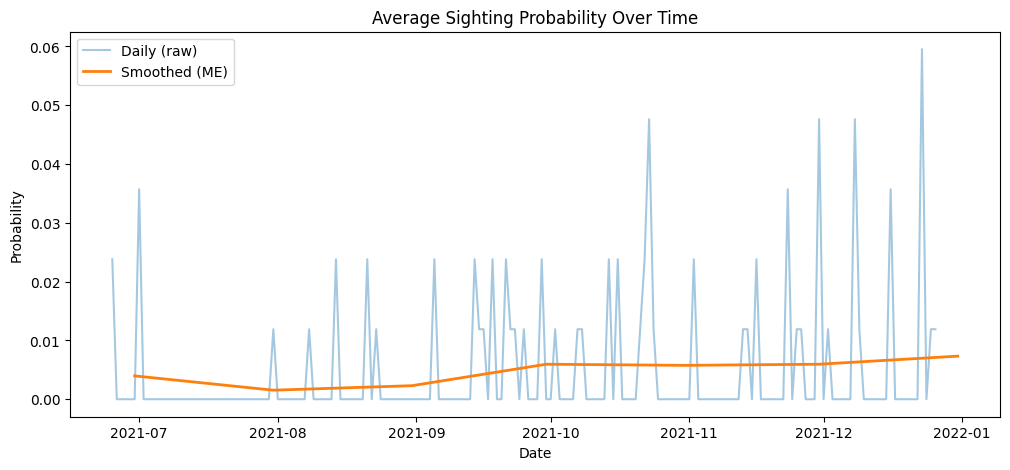

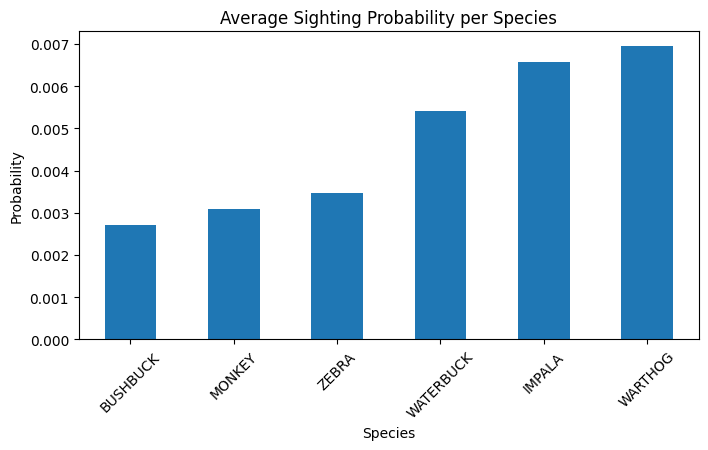

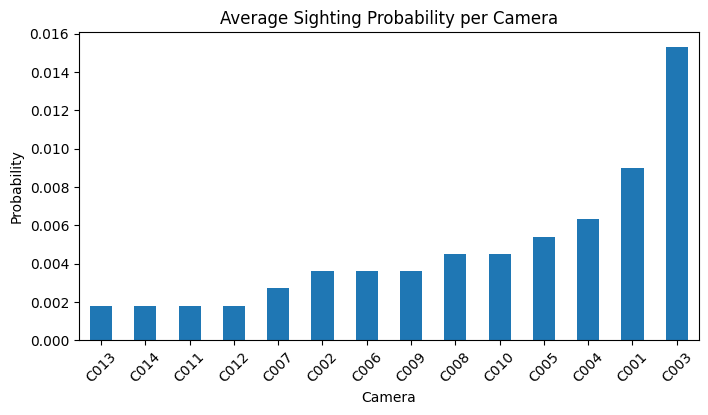

In [ ]:
#TODO Exercise 3

Exercise 3 Extended: Which of these relationships you found are statistically significant?

In [ ]:
#TODO Exercise 3 Extended

### Address

Using the data we collected in the Access stage and understood in Assess, we can now Address our question, and create a naive Bayesian classification model for predicting the probability of a camera sighting a species on a given day.

$$
\text{P}(1 \mid c, s, d) = P(1) \cdot P(c \mid 1) \cdot P(s \mid 1) \cdot P(d \mid 1)
$$

$$
\text{Using Bayes' rule:} \quad P(c \mid 1) = \frac{P(1 \mid c) \cdot P(c)}{P(1)} \quad \text{(and similarly for } s, d\text{)}
$$

$$
\Rightarrow \text{P}(1 \mid c, s, d) = P(1) \cdot \frac{P(1 \mid c) \cdot P(c)}{P(1)} \cdot \frac{P(1 \mid s) \cdot P(s)}{P(1)} \cdot \frac{P(1 \mid d) \cdot P(d)}{P(1)}
$$

$$
= \frac{P(1 \mid c) \cdot P(1 \mid s) \cdot P(1 \mid d) \cdot P(c) \cdot P(s) \cdot P(d)}{P(1)^2}
$$

$$
\begin{align*}
&c = \text{camera ID (e.g., C001)} \\
&s = \text{species (e.g., IMPALA)} \\
&d = \text{smoothed date (e.g., month, or Gaussian-filtered day)}
\end{align*}
$$


### Exercise 4

Implement the model below.

In [ ]:
from typing import Union
import pandas as pd
import numpy as np
from datetime import date as DateType

def bayes_sighting_probability(df, camera, species, date) -> float:
    """
    Removes a specific observation and estimates the probability of sighting
    a given species at a given camera on a specific date.

    Parameters:
        df (pd.DataFrame): DataFrame with MultiIndex columns (camera, species) and datetime.date index.
        camera (str): Camera ID (e.g. 'C001').
        species (str): Species name (e.g. 'IMPALA').
        date (str or datetime.date or pd.Timestamp): Date of the observation.

    Returns:
        float: Estimated sighting probability - TODO.
    """
    if isinstance(date, str) or isinstance(date, pd.Timestamp):
        date = pd.to_datetime(date).date()

    df_blind = df.copy()
    df_blind.loc[date, (camera, species)] = None

    #TODO Exercise 4

    raise NotImplementedError("Prediction logic not implemented yet.")

Well done! We should now have a working Access-Assess-Address data science pipeline! Let's see how it does.

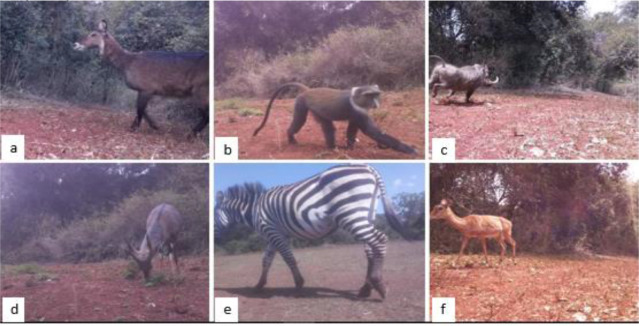

## Evaluation

The data is extremely sparse, with less than 1% of values being `1`. This is a challenge, as checking naive accuracy would make always-zero a very very good predictor.

Let's evaluate our prediction system using `log-loss` i.e. `cross-entropy`:

$$
\mathcal{L} = - \frac{1}{N} \sum_{i=1}^{N}
\Big[
    y_i \, \log(\hat{p}_i) + (1 - y_i) \, \log(1 - \hat{p}_i)
\Big]
$$

### Exercise 5

Implement the loss function below.

In [ ]:
def cross_entropy(y_true, y_pred):
    #TODO Exercise 5
    raise NotImplementedError("Cross entropy not implemented yet.")

def evaluate_prediction_system(df, your_function, max_samples=1000):
    # Randomly sample up to 1000, if full evaluation taking too long
    np.random.seed(42)
    coords = [(date, camera, species) for date in df.index for (camera, species) in df.columns]
    if len(coords) > max_samples:
        coords = np.random.choice(len(coords), size=max_samples, replace=False)
        coords = [coords[i] if isinstance(coords[i], tuple) else
                  [(date, camera, species) for date in df.index for (camera, species) in df.columns][coords[i]]
                  for i in range(len(coords))]
    else:
        coords = coords

    y_true = []
    y_pred = []

    for date, camera, species in coords:
        value = df.loc[date, (camera, species)]
        y_true.append(value)
        prob = your_function(df, camera, species, date)
        y_pred.append(prob)

    return cross_entropy(y_true, y_pred)

# Let's pass our function to be evaluated. This could take quite some time if your function is complex.
evaluate_prediction_system(binary_df, bayes_sighting_probability)

np.float64(0.02480092265440149)

For reference, predicting a constant probability (eg. `0.5%`) gives a loss of around `0.026`. This should be the benchmark number we want to improve on. If your model does better than that, well done!

*Note: our approach included look-ahead bias - making predictions based on data that we would not have access to at the time. For real-life deployment, we would need to limit our training data to before individual test cases.*

## Improving our methods

### Correlated Variables

The model above was quite simplified, and it disregarded any correlations between the three variables. Since cameras are close to each other, maybe they are more likely to capture the same animals on the same day? Maybe some animals like or avoid some areas, or some other animals? If any of the above is true, we can't really be using simple Bayes' rule classification.

### Exercise 6

Analyse the data again to find the strongest relationships which can be used to improve predictions. Plot correlation matrices and other helpful charts.

Have a short read through the [DSAIL-Porini paper](https://www.sciencedirect.com/science/article/pii/S2352340922010666) for inspiration about other probability analyses that can be done here.

In [ ]:
#TODO Exercise 6

Exercise 6 Extended: Use what you found above to improve on your prediction model, and compare it against the previous one.

In [ ]:
from typing import Union
import pandas as pd
import numpy as np
from datetime import date as DateType

def improved_sighting_probability(df, camera, species, date) -> float:
    """
    Removes a specific observation and estimates the probability of sighting
    a given species at a given camera on a specific date.

    Parameters:
        df (pd.DataFrame): DataFrame with MultiIndex columns (camera, species) and datetime.date index.
        camera (str): Camera ID (e.g. 'C001').
        species (str): Species name (e.g. 'IMPALA').
        date (str or datetime.date or pd.Timestamp): Date of the observation.

    Returns:
        float: Estimated sighting probability - TODO.
    """
    if isinstance(date, str) or isinstance(date, pd.Timestamp):
        date = pd.to_datetime(date).date()

    df_blind = df.copy()
    df_blind.loc[date, (camera, species)] = None

    #TODO Exercise 6 Extended

    raise NotImplementedError("Prediction logic not implemented yet.")

### Databases

Throughout the course you will work with various datasets and data formats. An SQL database is one of the most common ways to store large amounts of data. We recognise that many of you may be familiar with this already, but let's use this example to build a small toy database of animal sightings based on the excel file and the dataframes we created.

### Exercise 7

- Create a local database (eg. `sqlite3`).
- Add a table with animal sighting data.
- Add a table with camera coordinates data.
- Set indices on columns you might search by (eg. `CameraID`, `Date`). Make sure the index types make sense!
- Look into multi column indices, and set one on `Latitude` and `Longitude`.
- Demonstrate success with a couple SQL queries, eg. counting `IMPALA` sightings within a `200m` square around `-0.3866, 36.9649`.

Helpful links:

[SQL Intro, Creating Tables, Indices, Joins](https://www.w3schools.com/sql/sql_intro.asp)

[Multi-Column Indices](https://stackoverflow.com/questions/179085/multiple-indexes-vs-multi-column-indexes)

Remember to include reusable code from this and previous exercises in your Fynesse library!

In [ ]:
#TODO Exercise 7

### Extended Exercises

We didn't use all of the available data when we just classified days as "sighting" or "no sighting". Extend your analysis to include all the information in the file, like numbers of sightings, and numbers of animals in the photos.

This will be quite challenging due to burst shots - assess the dataset and come up with a good definition of what a burst is, and a data structure that has the information you chose as important.

Example burst data:
- Camera, Date, Species
- Time Start, Time End
- Number of photos
- Average/most animals in a photo

*Particular challenge around deduplicating multi-species sightings.*

#### Exercise 8
Use this additional data and repeat the analysis you did above. Aim to further improve predictions and write a new function like `burst_sighting_probability('C001', 'IMPALA', '2021-12-24')`.

In [ ]:
#TODO Exercise 8

#### Exercise 9
Compare the results and note the improvement (or lack thereof) against the two previous prediction functions you created.

In [ ]:
#TODO Exercise 9

#### Exercise 10
What other benefits does your new system provide? Can you modify it to provide more predictions, like expected number of sightings, number of animals?

In [ ]:
#TODO Exercise 10

End of Practical 2
```
 _______  __   __  _______  __    _  ___   _  _______  __
|       ||  | |  ||   _   ||  |  | ||   | | ||       ||  |
|_     _||  |_|  ||  |_|  ||   |_| ||   |_| ||  _____||  |
  |   |  |       ||       ||       ||      _|| |_____ |  |
  |   |  |       ||       ||  _    ||     |_ |_____  ||__|
  |   |  |   _   ||   _   || | |   ||    _  | _____| | __
  |___|  |__| |__||__| |__||_|  |__||___| |_||_______||__|
```